# Determinación del primer coeficiente de Lyapunov (Guckenheimer)

In [1]:
PP[u_, v_, A_, Q_] := ((1-u)(u^2+A^2)-Q*u*v)u^2;
QQ[u_, v_, A_, B_] := B(u-v)(u^2+A^2)v;

In [3]:
h1[u_, v_, A_, Q_] = PP[u + H, v + H, A, Q] ;
h2[u_, v_, A_, B_] = QQ[u + H, v + H, A, B] ;
F1[u_, v_, A_, Q_] = h1[u, v, A, Q] - a*u - b*v ; 
F2[u_, v_, A_, B_] = h2[u, v, A, B] - a*u + a*v ;
G1[u_, v_, A_, B_, Q_] = (1/d)(F1[d*u + v, v, A, Q] - F2[d*u + v, v, A, B]) ;
G2[u_, v_, A_, B_] = F2[d*u + v, v, A, B] ;

2           2                                   2    2
 H  (m + n - H  Q)   (a + b - 3 H m - 4 H n - 2 (A  - H  + n) Q) Y
(----------------- - --------------------------------------------- + 
         d                                 d
 
        2                2                    2     2                          3
      (A  (1 - 3 H) - 2 H  (-3 + 5 H + 3 Q)) Y    (A  + 2 H (-2 + 5 H + 2 Q)) Y
>     ----------------------------------------- - ------------------------------ - 
                          d                                     d
 
                      4    5
      (-1 + 5 H + Q) Y    Y        7
>     ----------------- - -- + O[Y] ) + 
              d           d
 
           2                  2
>   (-(H (A  B - 3 m - 4 n + H  (B + 3 Q))) + 
 
         2                         2
>      (A  (3 - B) + 6 m + 13 n - H  (1 + 3 B + 9 Q)) Y - 
 
           2                             2                         3      4       7
>      3 (A  + H (-4 + B + 10 H + 3 Q)) Y  + (4 - B - 20 H - 3 Q) Y  - 5 Y  + O[Y] ) X + 
 
           2                 2
     d (3 A  + 6 m + 13 n - H  (1 + 4 B + 6 Q))
>   (------------------------------------------ - 
                         2
 
             2                                                              2
>      d (3 A  + 4 B H + 6 H (-2 + 5 H + Q)) Y - d (-6 + 2 B + 30 H + 3 Q) Y  - 
 
             3       7   2       2   2
>      10 d Y  + O[Y] ) X  + (-(d  (A  + H (-4 + B + 10 H + Q))) - 
 
        2                             2  2       7   3
>      d  (-4 + B + 20 H + Q) Y - 10 d  Y  + O[Y] ) X  + 
 
      3                3         7   4    4  5       7
>   (d  (1 - 5 H) - 5 d  Y + O[Y] ) X  - d  X  + O[X]
                   2    2           2      2               2        3       7
((-(a d) + B d H (A  + H )) + B d (A  + 3 H ) Y + 3 B d H Y  + B d Y  + O[Y] ) X + 
 
          2  2        2            2  2       7   2       3        3         7   3
>   (2 B d  H  + 4 B d  H Y + 2 B d  Y  + O[Y] ) X  + (B d  H + B d  Y + O[Y] ) X  + 
 
        7
>   O[X]
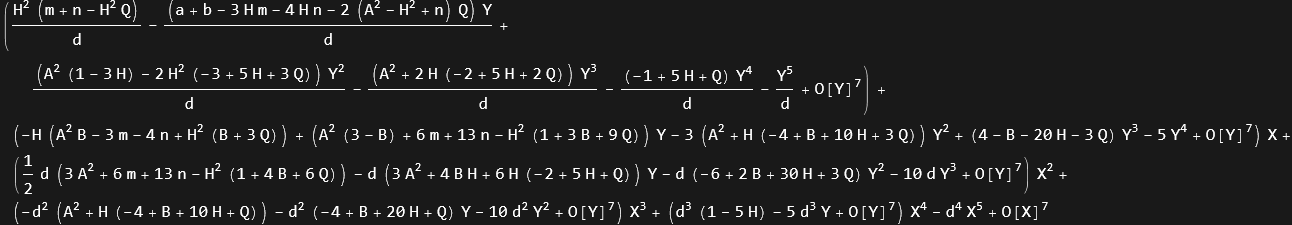

In [9]:
asumir = {a > 0, b < 0, d > 0, m > 0, n > 0, 0 < A < (H* Sqrt[1 - 2*H]), B > 0,  0 < H < (1/2), Q > 0};

restricciones = {
  m == H^3 + A^2*(2 - H),
  n == H^2*(1 - 2*H) - A^2,
  d == Sqrt[m/n],
  A^2 + H^2 == (m + n)/(1 - H)
};

simplificarMN[expr_] := FullSimplify[
   expr,
   restricciones, 
   Assumptions -> asumir
];

expansionG1 = simplificarMN[Series[G1[X, Y, A, B, Q], {X, 0, 6}, {Y, 0, 6}]]
expansionG2 = simplificarMN[Series[G2[X, Y, A, B], {X, 0, 6}, {Y, 0, 6}]]
G1SerieTaylor[X_, Y_] = Normal[expansionG1];
G2SerieTaylor[X_, Y_] = Normal[expansionG2];

Las anteriores expanciones en series de potencias contienen todos los terminos de la parte no lineal del sistema polinomial de orden 5. Al reemplazar las variables, los terminos lineales se anulan en estas expresiones, por ejemplo:

In [16]:
(* m+n-Q*H^2 *)
FullSimplify[(H^3 + A^2*(2 - H)) + (H^2*(1 - 2*H) - A^2) - ((1 - H)(A^2 + H^2)/H^2)*H^2]

0

2                 2
d (3 A  + 6 m + 13 n - H  (1 + 4 B + 6 Q))
 2                2
A  (2 - 6 H) - 4 H  (-3 + 5 H + 3 Q)
------------------------------------
                 d
   2                           2
-(A  (-3 + B)) + 6 m + 13 n - H  (1 + 3 B + 9 Q)
    2   2
-6 d  (A  + H (-4 + B + 10 H + Q))
     2
-6 (A  + H (-4 + B + 10 H + 3 Q))
     2  2
4 B d  H
0
      2      2
B d (A  + 3 H )
     2
8 B d  H
0
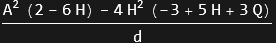

In [18]:
G1xx  = FullSimplify[Derivative[2,0][G1SerieTaylor][0,0], asumir]
G1yy  = FullSimplify[Derivative[0,2][G1SerieTaylor][0,0], asumir]
G1xy  = FullSimplify[Derivative[1,1][G1SerieTaylor][0,0], asumir]
G1xxx  = FullSimplify[Derivative[3,0][G1SerieTaylor][0,0], asumir]
G1xyy  = FullSimplify[Derivative[1,2][G1SerieTaylor][0,0], asumir]

G2xx  = FullSimplify[Derivative[2,0][G2SerieTaylor][0,0], asumir]
G2yy  = FullSimplify[Derivative[0,2][G2SerieTaylor][0,0], asumir]
G2xy  = FullSimplify[Derivative[1,1][G2SerieTaylor][0,0], asumir]
G2xxy  = FullSimplify[Derivative[2,1][G2SerieTaylor][0,0], asumir]
G2yyy  = FullSimplify[Derivative[0,3][G2SerieTaylor][0,0], asumir]

In [28]:
B = (H^2(1 - 2H) - A^2)/(A^2 + H^2);
Q = (1 - H)(A^2 + H^2)/H^2;
a = H(H^2(1-2H)-A^2);
b = -H((1-H)(A^2+H^2));
d = Sqrt[(H^3+A^2(2-H))/(H^2(1-2H) - A^2)];
m = H^3 + A^2*(2 - H);
n = H^2*(1 - 2*H) - A^2;
omega = H Sqrt[m*n];

coeficientelyapunov = (1/16) * (
  (G1xxx + G1xyy + G2xxy + G2yyy) +
  (1/omega) * (G1xy*(G1xx + G1yy) - G2xy*(G2xx + G2yy) - G1xx*G2xx + G1yy*G2yy)
);

l1[a_, h_] := coeficientelyapunov /. {A -> a, H -> h};

Table[
  Module[{h, maxa, a},
    h = RandomReal[{0.001, 0.499}];
    maxa = Sqrt[h^2 (1 - 2 h)];
    a = RandomReal[{0.001, maxa}];
    {a, h, l1[a, h]}
  ],
  {10}
]

{{0.0470159, 0.297253, -0.0164054}, {0.0395839, 0.32076, -0.0120774}, 
 
>   {0.114105, 0.438573, -0.322162}, {0.0581197, 0.362827, -0.0285321}, 
 
>   {0.140804, 0.35604, -0.218279}, {0.104888, 0.325801, -0.0836716}, 
 
>   {0.00819394, 0.119054, -0.000880801}, {0.0886237, 0.459868, -0.246464}, 
 
>   {0.0280541, 0.238314, -0.00621806}, {0.135148, 0.222358, -0.0932396}}

2                 2  3             5    4
A  (-1 + H) H (-4 A  H  + (-3 + H) H  + A  (4 + 3 (-3 + H) H))
--------------------------------------------------------------
        2    2      2              3    2    2
    2 (A  + H ) (-(A  (-2 + H)) + H ) (A  + H  (-1 + 2 H))
          5    4                          2  3
(-3 + H) H  + A  (4 + 3 (-3 + H) H) == 4 A  H
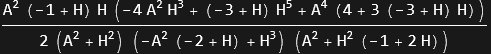

In [39]:
l1 = FullSimplify[coeficientelyapunov, asumir]
FullSimplify[l1 == 0, asumir]
Clear[a, b, d, m, n, A, B, H, Q, omega];

Legended[Legended[-Graphics-, Placed[SwatchLegend[{Directive[EdgeForm[Directive[
 
>          AbsoluteThickness[2.], Dashing[{Small, Small}], GrayLevel[0.5]]], 
 
>        AbsoluteThickness[2.], Opacity[0.15], GrayLevel[0.5]]}, 
 
>      {Restricciones del Sistema}, LegendMarkers -> Automatic, LabelStyle -> {}, 
 
>      LegendLayout -> Column], After, Identity]], 
 
>   Placed[LineLegend[{Directive[AbsoluteThickness[2], Thickness[0.006], GrayLevel[0]]}, 
 
>     {L_1 = 0}, LegendMarkers -> None, LabelStyle -> {}, LegendLayout -> Column], 
 
>    After, Identity]]
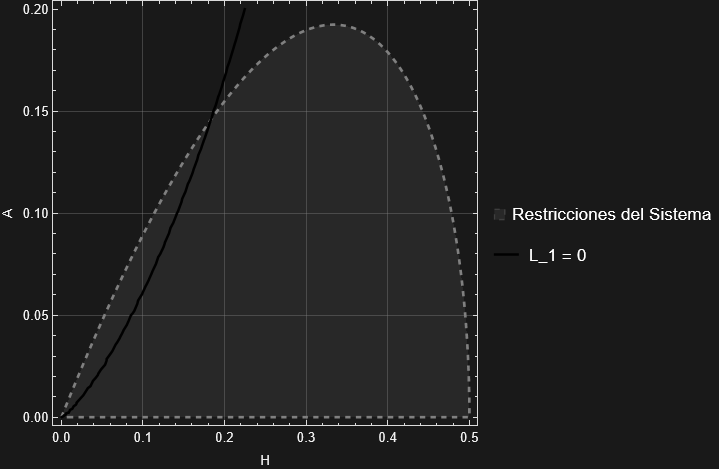

In [42]:
ecuacionL1 = (3H(3-H)-4)A^4 + 4H^3A^2 + (3-H)H^5  == 0;

regionValida = H < 1/2 && A^2 < H^2*(1 - 2*H);

plot = Show[
  RegionPlot[regionValida, {H, 0, 0.5}, {A, 0, 0.2}, 
    PlotStyle -> Directive[Opacity[0.15], Gray], 
    BoundaryStyle -> Directive[Dashed, Gray],
    PlotLegends -> {"Restricciones del Sistema"}
  ],
  ContourPlot[Evaluate[ecuacionL1], {H, 0, 0.5}, {A, 0, 0.2}, 
    ContourStyle -> {Thickness[0.006], Black},
    PlotLegends -> {"L_1 = 0"}
  ],
  
  FrameLabel -> {"H", "A"},
  GridLines -> Automatic
]

## Segundo coeficiente de Lyapunov

In [45]:
Ac =  Sqrt[(2H^3 + H^2(1 - H) Sqrt[3H(4 - H)])/(4-3H(3-H))] ;
B[A_] = (H^2(1 - 2H) - A^2)/(A^2 + H^2) ;
Q[A_] = (1 - H)(A^2 + H^2)/H^2 ;
a[A_] = H(H^2 (1-2H)-A^2) ;
b[A_] = -H(1-H)(A^2+H^2) ;
m[A_] = H^3+A^2(2-H) ;
n[A_] = H^2(1-2H) - A^2 ;
d[A_] = Sqrt[m[A]/n[A]] ;
omega[A_] = H Sqrt[m[A]*n[A]] ;

I m
{1 + ---------, 1}
     Sqrt[m n]
       I n
{----------------, 1}
 -I n + Sqrt[m n]
     (I + d) m
-------------------
d (m + I Sqrt[m n])
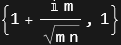
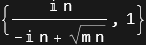
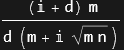

In [75]:
jac = {{a[A], b[A]}, {a[A], -a[A]}};
q = simplificarMN[Eigenvectors[jac]][[2]]
p = simplificarMN[Eigenvectors[Transpose[jac]]][[1]]
p1 = ComplexExpand[(1/2)*(1 - I/d)*p];
FullSimplify[Conjugate[p1].q, asumir]

Reemplazando d en la última expresión, el producto escalar es igual a 1. Determinando así que p1 es el vector requerido para la normalización necesaria. Además se verifica que este es un vector propio:

H n    1  H (I m + d n)
{---, -(-) -------------}
  2     2        d
                 1
              (-(-) I) (-I + d) H Sqrt[m n]
 H Sqrt[m n]     2
{-----------, -----------------------------}
     2 d                    d
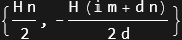
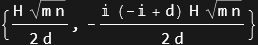

In [72]:
pp1 = (1/2)*{I/d, 1 - I/d}; (* p1 simplificado*)
simplificarMN[Transpose[jac].pp1]
simplificarMN[-I*omega[A]*pp1] (* Sí, es vector propio (reemplace d) *)

In [114]:
operarComplejos[expr_] := Assuming[asumir, Refine[expr]];
primerCom = operarComplejos[z*q[[1]] + w*Conjugate[q[[1]]]];
segundoCom = operarComplejos[z*q[[2]] + w*Conjugate[q[[2]]]];

Definimos la función de variable compleja:

4                       2  2
(((I A  (I + d) (-1 + H) m + A  H  ((3 + (2 I) d (-1 + H) - 2 H) m - 
 
>             I (-2 + H) Sqrt[m n]) + 
 
                            3      4                        4
>          H (I d (-1 + H) H  m + H  m + I b Sqrt[m n] + I H  Sqrt[m n] + 
 
>             I a (d m + Sqrt[m n]))) w) / (2 d H Sqrt[m n]) + 
 
           4
>     ((I A  (I + d) (-1 + H) Sqrt[m n] + 
 
            2  2
>          A  H  (2 (I (-2 + H) + d (-1 + H)) m - I (-5 + 3 H) n + 
 
>             (11 + (4 I) d (-1 + H) - 7 H) Sqrt[m n]) + 
 
            4
>          H  ((I + 2 d (-1 + H) - (5 I) H) m - (3 I) d Sqrt[m n] + 
 
                                                       2          2
>             H ((4 I) n + (8 + (3 I) d) Sqrt[m n]))) w ) / (2 d H  n) + 
 
                             2
>     (m (m + I Sqrt[m n]) (H  ((2 - I d (-1 + H) - 8 H) m + 6 H n - 3 d Sqrt[m n] + 
 
>             3 (-4 I + d) H Sqrt[m n]) + 
 
            2
>          A  ((-2 - I d (-1 + H) + H) m + (4 - 3 H) n + 
 
                                                          3                3/2
>             (-8 I - 3 d + (6 I) H + 3 d H) Sqrt[m n])) w ) / (2 d H (m n)   ) + 
 
                           2      2
>     (m (-I m + Sqrt[m n])  (-I A  (-1 + H) n (-((2 I + d) m) + Sqrt[m n]) + 
 
            2
>          H  (I d (-1 + H) m n + 8 H m n + I m Sqrt[m n] - (5 I) H m Sqrt[m n] + 
 
                                                                               5  5
                                     4          2      5/2    (m + I Sqrt[m n])  w
>             (4 I) H n Sqrt[m n])) w ) / (2 d H  (m n)   ) + --------------------- + 
                                                                           5/2
                                                                  2 d (m n)
 
          7       4
>     O[w] ) + ((A  (1 - I d) (-1 + H) m + 
 
           2  2
>         A  H  ((-3 - (2 I) d (-1 + H) + 2 H) m - I (-2 + H) Sqrt[m n]) + 
 
                             3         4                    4
>         I H (-(d (-1 + H) H  m) + I H  m + b Sqrt[m n] + H  Sqrt[m n] + 
 
>            a (-(d m) + Sqrt[m n]))) / (2 d H Sqrt[m n]) + 
 
          2
>      ((A  ((-2 I) (-2 + H) m - 2 d (-1 + H) m + I (5 - 3 H) n) + 
 
             2
>           H  ((-I + 2 d + (5 I) H - 2 d H) m + (4 I) H n)) w) / (d n) + 
 
            2                                2
>      (m (A  ((6 + (3 I) d (-1 + H) - 3 H) m  - (3 I) (-4 + 3 H) n Sqrt[m n] + 
 
>              m (3 (4 + I d (-1 + H) - 3 H) n + 
 
>                 (10 I - 4 d (-1 + H) - (7 I) H) Sqrt[m n])) + 
 
             2                               2
>           H  (3 (-2 + I d (-1 + H) + 8 H) m  + (18 I) H n Sqrt[m n] + 
 
>              m (18 H n - (2 I) Sqrt[m n] + (20 I) H Sqrt[m n] - 
 
                                                          2                3/2
>                 d (-1 + H) ((-3 I) n + 4 Sqrt[m n])))) w ) / (2 d H (m n)   ) + 
 
            2                        2
>      ((I A  (-1 + H) n ((2 I + d) m  + (4 I + d) m n - 2 n Sqrt[m n]) + 
 
             2                           2            2
>           H  ((I d (-1 + H) + 16 H) m n  + (8 I) H n  Sqrt[m n] + 
 
                2                                                               3
>              m  ((-2 + I d (-1 + H) + 18 H) n + (2 I) (1 - 5 H) Sqrt[m n]))) w ) / 
 
                                                           3  4
            2  2              5 m (m + n) (m + I Sqrt[m n])  w        7
>       (d H  n  Sqrt[m n]) - --------------------------------- + O[w] ) z + 
                                                 5/2
                                        2 d (m n)
 
                            2    2         2      2
         (I + d) (-1 + H) (A  + H ) m (-I A  n + H  ((-3 I) n + 2 Sqrt[m n]))
>   ((m (-------------------------------------------------------------------- + 
                                           2
                                          H
 
                
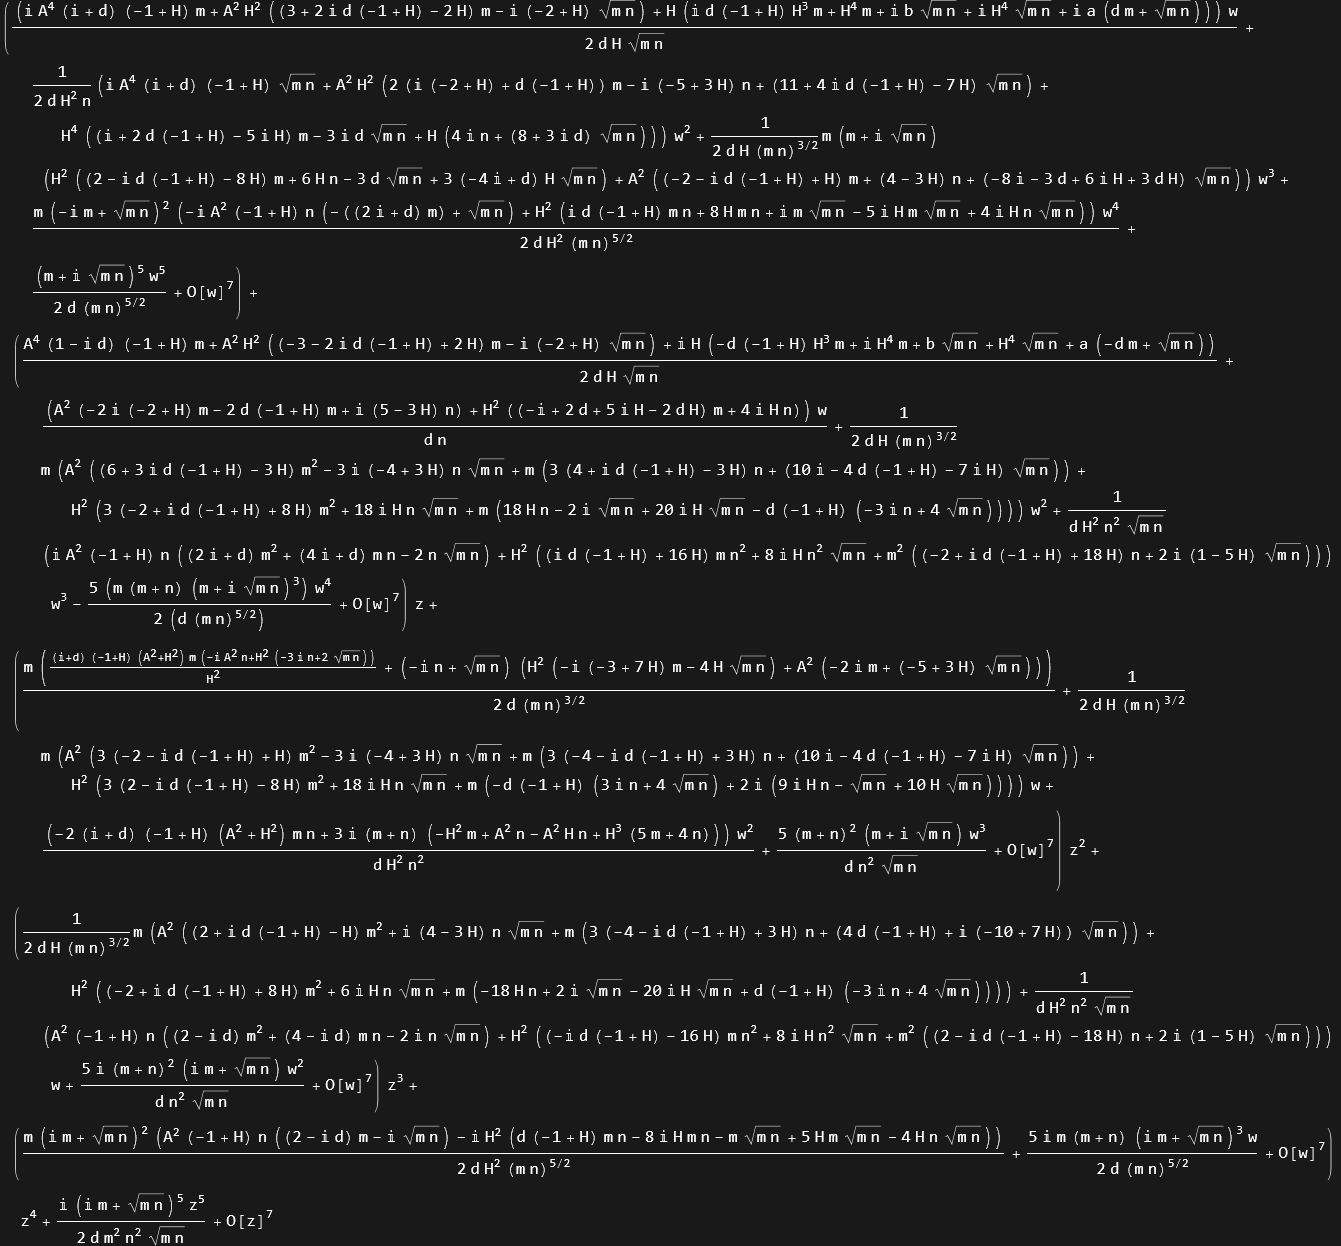

In [133]:
G[z_, w_] = Series[operarComplejos[Conjugate[pp1[[1]]]*F1[primerCom, segundoCom, A, Q[A]] + Conjugate[pp1[[2]]]*F2[primerCom, segundoCom, A, Q[A]]], {z, 0, 6}, {w, 0, 6}]

In [233]:
Clear[a, b, d, m, n, A, B, H, Q, omega];
B = (H^2(1 - 2H) - A^2)/(A^2 + H^2);
Q = (1 - H)(A^2 + H^2)/H^2;
a = H(H^2(1-2H)-A^2);
b = -H((1-H)(A^2+H^2));
d = Sqrt[(H^3+A^2(2-H))/(H^2(1-2H) - A^2)];
m = H^3 + A^2*(2 - H);
n = H^2*(1 - 2*H) - A^2;
omega = H Sqrt[m*n];

g20 = FullSimplify[Derivative[2,0][G][0,0]];
g11 = FullSimplify[Derivative[1,1][G][0,0]];
g21 = FullSimplify[Derivative[2,1][G][0,0]];

In [ ]:
product1 = FullSimplify[I*g20*g11]

In [ ]:
product2 = omega*g21

In [43]:
CopyToClipboard[l1]